# Module 3.3 — Routing Quality, Safety, Cost, Latency

This notebook is the main interface for Module 3.3. Edit only the configuration section, then run all cells.

In [1]:
# Install package
# - Colab: keep the GitHub install.
# - Local dev: comment out GitHub line and use editable install from repo root.
#
# %pip install -q -e .
%pip install -q git+https://github.com/mnrozhkov/ai-leader.git

/Users/mnrozhkov/dev/ai-leader/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
from pprint import pprint

import pandas as pd
from dotenv import load_dotenv
from IPython.display import display

from ai_leader import (
    DEFAULT_SYSTEM_PROMPT,
    MODEL_PALETTE,
    build_comparison_table,
    create_client,
    display_evaluation_results,
    evaluate_model_on_dataframe_async,
    load_and_validate_dataset,
    run_model_comparison_async,
)
from ai_leader.reporting import (
    plot_confidence_buckets,
    plot_quality_vs_cost,
)

## Configuration

Edit these values before running the notebook.

In [2]:
load_dotenv(".env", override=False)

mode = os.getenv("AI_LEADER_CLIENT", "TOKEN_FACTORY").strip().upper()
api_key = os.getenv("TOKENFACTORY_API_KEY")
if not api_key and mode == "TOKEN_FACTORY":
    api_key = input("Paste API key: ").strip()

# Dataset
DEFAULT_DATASET_URL = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSU5zvx8wgk9FMEcRGlCtXkE4_T90OgsrqU4QPNZC478Rsp5JEBEEUjvlMkY3iMoiAmpa1zQ5QFkgT5/pub?output=csv"
DATASET_URL = os.getenv("AI_LEADER_DATASET_PATH", DEFAULT_DATASET_URL)

# Model candidates
CANDIDATE_MODELS = [
    "deepseek-ai/DeepSeek-V3.2",
    "zai-org/GLM-5",
    "openai/gpt-oss-120b",
]

# Prompt settings
SYSTEM_PROMPT = DEFAULT_SYSTEM_PROMPT
TEMPERATURE = 0.2

# Confidence policy
HIGH_CONFIDENCE_LABEL = "High"

# Unit economics assumptions
MONTHLY_MESSAGES = 20_000

## Load and validate dataset

In [3]:
df = load_and_validate_dataset(DATASET_URL)

print(f"Dataset shape: {df.shape}")
df.tail(3)

Dataset shape: (100, 9)


,Request Text,Submission Channel,Related to order,Order ID,Category,Routing to Department,Timestamp,Order History,row_id
97,The delivery truck is too big for my small str...,Chat,True,CK-5588,Delivery,Logistics,2025-10-09 10:00:00,2025-10-01 — Order placed | 2025-10-09 — Lates...,97
98,Can I exchange my unused store credit for cash?,Email,False,NaN,General Feedback,Customer Support,2025-10-08 16:45:00,NaN,98
99,Where is my order? I placed it almost two week...,Email,True,CK-5678,Delivery,Customer Support,2025-10-08 16:00:00,2025-09-21 — Order placed for Accessories; pay...,99


In [4]:
display(df["Category"].value_counts())
display(df["Routing to Department"].value_counts())

Category
Delivery            28
Order Issue         27
General Feedback    24
Payment             21
Name: count, dtype: int64

Routing to Department
Logistics           29
Customer Support    27
Product Team        23
Returns             21
Name: count, dtype: int64

## Run model comparison

In [6]:
client = create_client(api_key, mode=mode)

try:
    model_runs = await run_model_comparison_async(
        df=df.sample(frac=0.3),  # Use 30% of the dataset for comparison
        models=CANDIDATE_MODELS,
        client=client,
        system_prompt=SYSTEM_PROMPT,
        temperature=TEMPERATURE,
        monthly_messages=MONTHLY_MESSAGES,
        use_progress=True,
    )
except Exception as exc:  # noqa: BLE001
    message = str(exc)
    if "Authentication" in message or "invalid_api_key" in message:
        print("Authentication failed. Check API key.")
    raise

comparison_table = build_comparison_table(model_runs)
comparison_table

Running openai/gpt-oss-120b: 100%|██████████| 30/30 [00:09<00:00,  3.13it/s]


,model,exact_match_rate,misroute_rate,category_accuracy,department_accuracy,cost_per_message_usd,monthly_cost_usd,median_latency_ms,p95_latency_ms
0,deepseek-ai/DeepSeek-V3.2,0.400000,0.600000,0.633333,0.533333,0.000070,1.4045,2378.847312,16473.500137
1,zai-org/GLM-5,0.400000,0.600000,0.500000,0.666667,0.001823,36.4536,15080.783854,40364.243585
2,openai/gpt-oss-120b,0.566667,0.433333,0.666667,0.766667,0.000183,3.6606,1758.696208,2511.092848


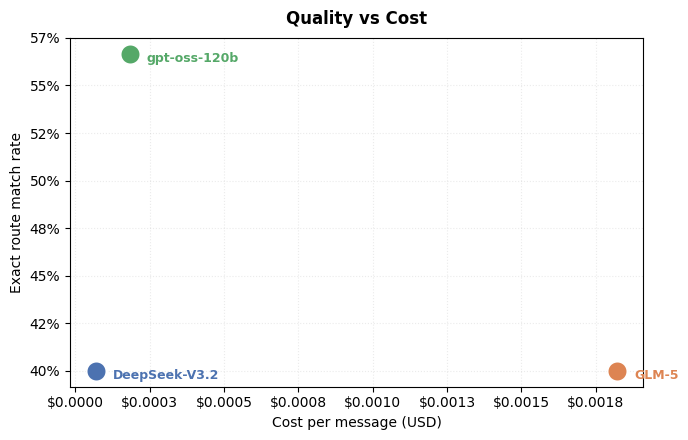

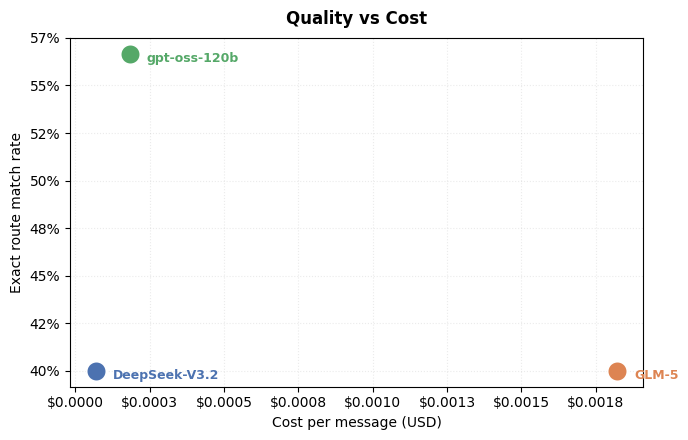

In [7]:
plot_quality_vs_cost(comparison_table)

## H2 — Routing quality

## Hypothesis

If the AI suggests the correct **Routing to Department**, then **misroutes stay ≤10%**.

## Primary metric

Use department only.

```text
exact_route_match = (pred_department == gold_department)
misroute_rate = 1 - mean(exact_route_match)
```

Equivalent:

* `exact_route_match_rate = department_accuracy`
* `misroute_rate = 1 - department_accuracy`

## Supporting metrics

Keep these as diagnostics:

* department accuracy
* department macro F1
* category accuracy
* category macro F1
* department confusion matrix
* category confusion matrix

## Decision rule

* **Pass**: `misroute_rate <= 0.10`
* **Fail**: `misroute_rate > 0.10`

So the notebook should treat **department accuracy** as the headline H2 metric.

---

In [14]:
BEST_MODEL = "openai/gpt-oss-120b"  # Select a model from the CANDIDATE_MODELS to proceed
h2_model = BEST_MODEL

print(f"H2 — full dataset run: {BEST_MODEL} ({len(df)} rows)")
h2_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=BEST_MODEL,
    client=client,
    system_prompt=SYSTEM_PROMPT,
    temperature=TEMPERATURE,
    monthly_messages=MONTHLY_MESSAGES,
    use_progress=True,
)

H2 — full dataset run: openai/gpt-oss-120b (100 rows)


Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?it/s]

Running openai/gpt-oss-120b: 100%|██████████| 100/100 [00:29<00:00,  3.37it/s]


category_accuracy           0.680000
category_f1_macro           0.668920
department_accuracy         0.570000
department_f1_macro         0.556678
exact_route_match_rate      0.460000
misroute_rate               0.540000
row_count                 100.000000


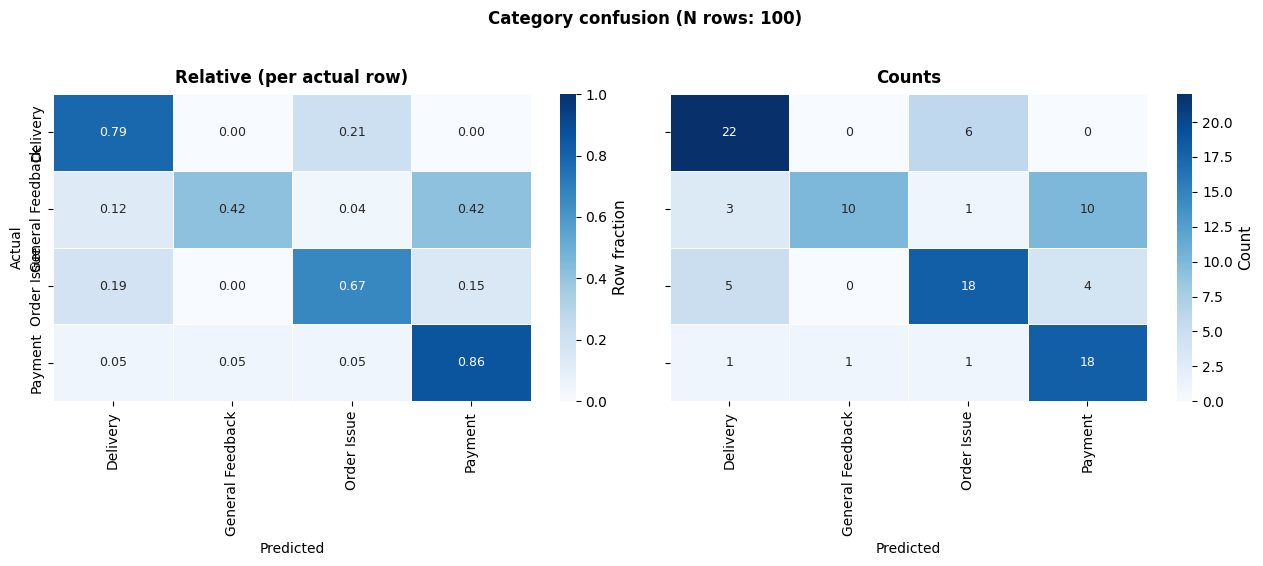

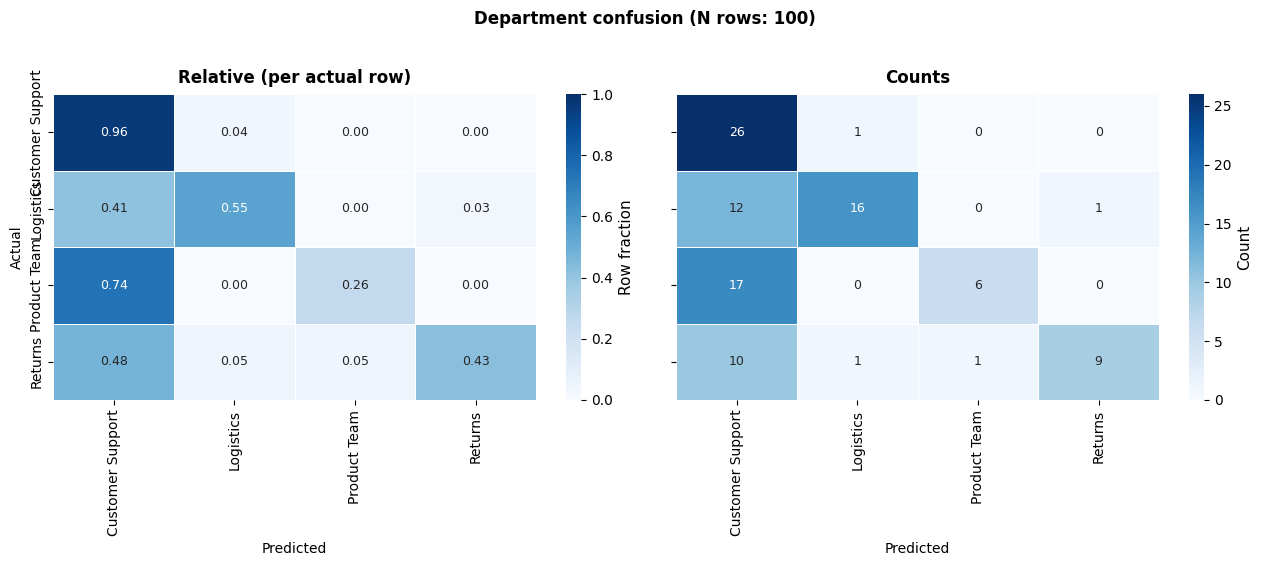

In [15]:
display_evaluation_results(eval_results=h2_run)

#### First: what the current result actually says

The current “best model” run is not close to validating H2.

With 100 rows:

- exact_route_match_rate = 0.46
- misroute_rate = 0.54

That means the current setup fails H2 by a wide margin.

The confusion matrices also show the main issue is not just category classification. The bigger problem is department routing. In particular, the model is often collapsing cases into Customer Support, which suggests:

- the routing policy is not explicit enough in the prompt,
- the task is overloaded by asking for routing and draft generation in one call,
- the dataset likely contains important distinctions such as:
    - `Delivery + Logistics` vs `Delivery + Customer Support`
    - `General Feedback + Product Team` vs `General Feedback + Customer Support`
    - `Order Issue + Returns` vs `Order Issue + Customer Support`

So the right next step is not “just try another model.”
It is to improve the **task definition, prompt, and evaluation slices**.

In [16]:
errors = h2_run.predictions.merge(df, on="row_id", suffixes=("_pred", "_gt"))
errors = errors[
    (errors["Category"] != errors["category"])
    | (errors["Routing to Department"] != errors["[Agent] Routing to Department"])
]
errors[
    [
        "Request Text",
        "Category",
        "category",
        "Routing to Department",
        "[Agent] Routing to Department",
    ]
].head()

,Request Text,Category,category,Routing to Department,[Agent] Routing to Department
0,My Autumn Oak table arrived with a cracked leg...,Order Issue,Delivery,Returns,Returns
1,I need to change my address for order CK-9902....,Delivery,Order Issue,Logistics,Customer Support
3,I love the new seasonal candle scents. The Pum...,General Feedback,Payment,Product Team,Customer Support
4,The toaster oven sparked when I plugged it in....,Order Issue,Payment,Product Team,Product Team
8,Instructions for the Lumina lamp are missing f...,Order Issue,Delivery,Product Team,Customer Support


### Improve system prompt 

In [ ]:
# Flow: optional spec in the next markdown cell
# define `DEFAULT_ROUTING_SYSTEM_PROMPT` in the code cell after that
# and run the re-evaluation cell.

# 1. Spec to improve `DEFAULT_ROUTING_SYSTEM_PROMPT`

## Problem with current prompt

The current routing prompt is too generic:

* it does not explain Candlekeep context,
* it does not define department ownership clearly,
* it does not explain hard routing distinctions,
* it mixes routing with response generation,
* it gives the model too little policy guidance.

That is especially harmful for department routing.

## Design goal

The prompt should help the model answer one question well:

**Which department should own this case?**

Category can stay in output, but the prompt should optimize primarily for department correctness.

## Prompt design principles

The new prompt should:

1. define the business setting briefly,
2. define the allowed labels explicitly,
3. define each department in operational terms,
4. explain common edge cases,
5. tell the model to prefer the **best owning department**,
6. return only routing fields needed for H2.

## Required behavior changes

For H2 evaluation, the routing prompt should **not** ask for:

* `[Agent] Initial Response`

It may still return:

* `Category`
* `Routing to Department`
* `Confidence`

But the prompt should make clear that **department routing is the primary objective**.

## Recommended prompt structure

The prompt should contain these blocks:

### A. Role

Example intent:

* support routing assistant for Candlekeep Retail Group

### B. Task

Example intent:

* assign exactly one Category and one Routing to Department
* prioritize choosing the right department owner

### C. Allowed labels

Explicit lists:

* Category: `Payment`, `Order Issue`, `Delivery`, `General Feedback`
* Routing to Department: `Customer Support`, `Returns`, `Product Team`, `Logistics`

### D. Department policy

This is the most important part.

Need short but concrete definitions:

* **Customer Support**
  General customer help, order follow-up, status clarification, general support coordination, cases that do not clearly belong to a specialist team.

* **Returns**
  Returns, exchanges, wrong item, missing item, damaged item, return workflow issues.

* **Product Team**
  App/site issues, product defects, product feedback, catalog/content issues.

* **Logistics**
  Shipment execution, carrier coordination, delivery access/scheduling, delivery operations.

### E. Key routing distinctions

This should be a dedicated section.

Must include cases like:

* Delivery topic does **not** always mean Logistics.
* Use `Customer Support` for general delivery status checks or non-operational follow-up.
* Use `Logistics` when operational delivery intervention is needed.
* Use `Product Team` for app/site/product issues, even if the tone is general feedback.
* Use `Returns` when the real action is exchange/return handling.

### F. Confidence guidance

Needed for later guardrail analysis:

* High = department is strongly supported
* Medium = some uncertainty
* Low = ambiguous or insufficient evidence

### G. Output rule

Return only valid JSON matching schema.
---

In [17]:
# Use something like this as the new baseline:

DEFAULT_ROUTING_SYSTEM_PROMPT = """
You are a support routing assistant for Candlekeep Retail Group.

Your task is to assign exactly one Category and exactly one Routing to Department
for each customer request.

Your primary goal is to choose the correct Routing to Department.
Use the customer request as the main evidence.
Use order history as supporting context when available.

Return only valid JSON matching the schema. Do not add extra keys.

Allowed Category values:
- Payment
- Order Issue
- Delivery
- General Feedback

Allowed Routing to Department values:
- Customer Support
- Returns
- Product Team
- Logistics

Department guidance:
- Customer Support: general customer help, order follow-up, status clarification,
  support coordination, and cases that do not clearly belong to a specialist team.
- Returns: returns, exchanges, wrong item, missing item, damaged item, and
  return workflow handling.
- Product Team: app issues, website issues, product defects, product feedback, and
  catalog/content problems.
- Logistics: shipment execution, carrier coordination, delivery scheduling,
  access problems, and logistics operations.

Important routing distinctions:
- A request about delivery status or tracking can still route to Customer Support
  if it mainly needs general follow-up or clarification.
- Use Logistics when operational delivery intervention is needed, such as carrier
  coordination, delivery access, scheduling, or shipment handling problems.
- Use Product Team for app, website, catalog, or product-quality issues, even if the
  message looks like general feedback.
- Use Returns when the main action is return, exchange, wrong-item, missing-item, or
  damaged-item handling.

Confidence guidance:
- High: the correct department is strongly supported by the request.
- Medium: there is some uncertainty between departments.
- Low: the request is ambiguous or lacks enough detail for reliable routing.
""".strip()

In [18]:
h2_run_new_prompt = await evaluate_model_on_dataframe_async(
    df=df,
    model=BEST_MODEL,
    client=client,
    system_prompt=DEFAULT_ROUTING_SYSTEM_PROMPT,
    temperature=TEMPERATURE,
    monthly_messages=MONTHLY_MESSAGES,
    use_progress=True,
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?it/s]

Running openai/gpt-oss-120b: 100%|██████████| 100/100 [00:29<00:00,  3.34it/s]


category_accuracy           0.850000
category_f1_macro           0.850140
department_accuracy         0.750000
department_f1_macro         0.752976
exact_route_match_rate      0.700000
misroute_rate               0.300000
row_count                 100.000000


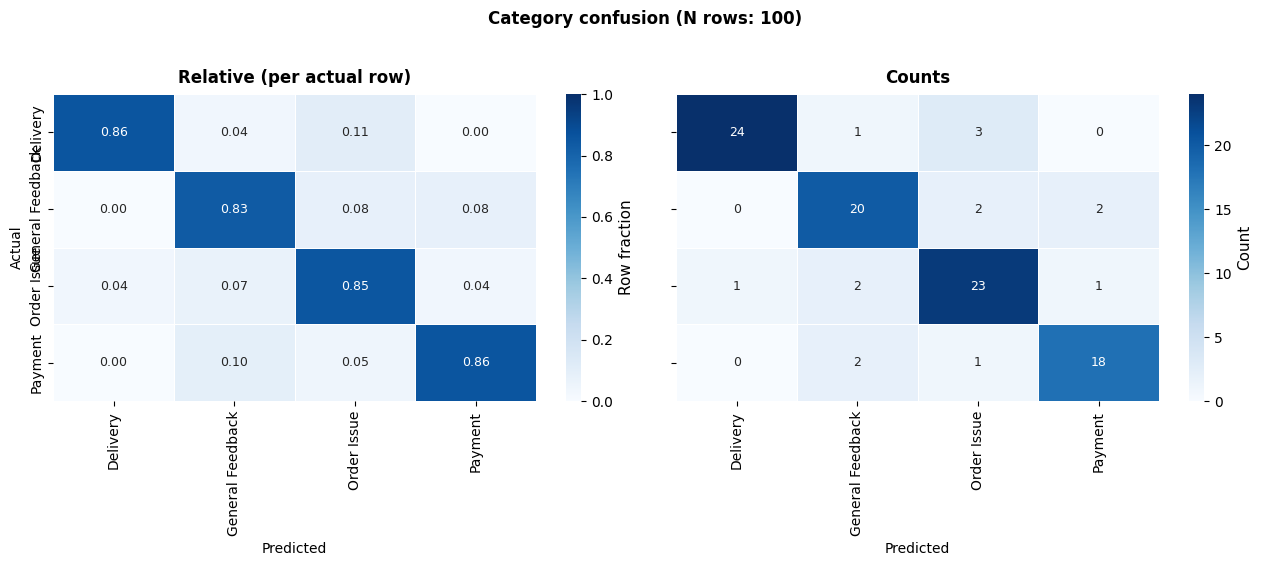

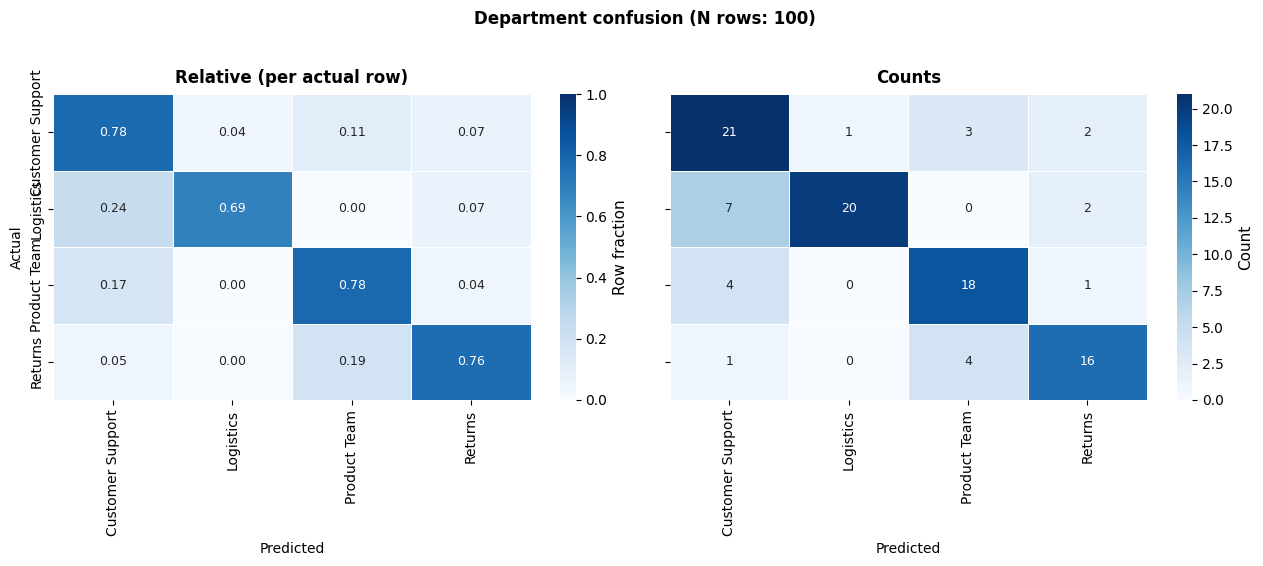

In [19]:
display_evaluation_results(eval_results=h2_run_new_prompt)

### Use (advanced) - Few-shot Ablation

```text

## Goal

Check whether adding a small number of carefully chosen examples improves **department routing quality**.

## Why use few-shot here

The main routing challenge is not generic language understanding.
It is learning Candlekeep-specific routing distinctions such as:

* `Delivery` → `Customer Support` vs `Logistics`
* `Order Issue` → `Returns` vs `Customer Support`
* `General Feedback` → `Product Team` vs `Customer Support`

Few-shot examples can teach those distinctions better than a generic prompt alone.

---

## Critical experiment rule

Use a **fixed evaluation set**.

Do **not** change the eval rows when changing shot count.

### Recommended split for 100 labeled rows

* **20 rows** = fixed few-shot pool
* **80 rows** = fixed evaluation set

The eval set must stay unchanged across:

* 0-shot
* 2-shot
* 4-shot
* 8-shot

That makes the comparison fair.

---

## Few-shot pool design

The 20-row few-shot pool should be selected deliberately, not randomly.

It should cover the main routing distinctions:

* Delivery → Customer Support
* Delivery → Logistics
* Order Issue → Returns
* Order Issue → Customer Support
* General Feedback → Product Team
* General Feedback → Customer Support
* Payment → Customer Support

It should also include:

* at least one ambiguous case,
* at least one case with useful order history,
* examples from different channels.

---

## What to measure in the ablation

For each shot count, compute:

### Primary H2 metrics

* exact route match rate = department accuracy
* misroute rate
* department macro F1

### Supporting metrics

* category accuracy
* category macro F1
* department confusion matrix
* confidence bucket counts

---

## Few-shot success criteria

A few-shot setup is better only if it improves department routing meaningfully.

Recommended evaluation logic:

* primary: higher department accuracy / lower misroute rate
* secondary: better department macro F1
* tertiary: no severe cost or latency penalty

### Practical notebook rule

Prefer a few-shot setting if:

* it improves department accuracy meaningfully,
* and improves difficult department distinctions,
* without unreasonable cost growth.
```

In [35]:
import matplotlib.pyplot as plt
from tqdm import tqdm

from ai_leader.clients import run_extraction_async
from ai_leader.config import DEFAULT_MAX_CONCURRENCY, MODEL_REGISTRY
from ai_leader.evaluation import compute_cost, compute_latency_summary, compute_quality_metrics

# --- User: model id for this ablation (must match your provider/registry entry) ---
BEST_MODEL = "openai/gpt-oss-120b"

FEW_SHOT_COUNTS = [0, 2, 4, 8, 16]
ABLATION_RANDOM_STATE = 42
FEW_SHOT_POOL_N = 32
ABLATION_EVAL_N = 68

abl_n = min(FEW_SHOT_POOL_N + ABLATION_EVAL_N, len(df))
if abl_n < 2:
    raise ValueError("Few-shot ablation needs at least two labeled rows.")
df_ablation = df.sample(n=abl_n, random_state=ABLATION_RANDOM_STATE).reset_index(drop=True).copy()
# Reserve ≥1 eval row; cap pool by available rows (small fixtures / CI).
_pool_cap = min(FEW_SHOT_POOL_N, abl_n - 1)
few_shot_pool_df = df_ablation.iloc[:_pool_cap].copy()
eval_df_fixed = df_ablation.iloc[_pool_cap:].copy()
# For a curated pool (spec), replace few_shot_pool_df with 20 hand-picked rows
# and keep them out of eval_df_fixed.

if eval_df_fixed.empty:
    raise ValueError(
        "Few-shot ablation needs at least one eval row after the few-shot pool; "
        f"increase labeled data or lower FEW_SHOT_POOL_N (pool={len(few_shot_pool_df)})."
    )

_ns_max = max(FEW_SHOT_COUNTS)
if _ns_max > len(few_shot_pool_df):
    FEW_SHOT_COUNTS = [n for n in FEW_SHOT_COUNTS if n <= len(few_shot_pool_df)]
    print(f"FEW_SHOT_COUNTS -> {FEW_SHOT_COUNTS} (pool has {len(few_shot_pool_df)} rows)")
if not FEW_SHOT_COUNTS:
    raise ValueError("No feasible n_shot values; enlarge the few-shot pool.")


phase2_predictions: dict[int, pd.DataFrame] = {}
ablation_rows: list[dict[str, object]] = []

print(
    f"Few-shot ablation slice: pool={len(few_shot_pool_df)} rows, "
    f"fixed eval={len(eval_df_fixed)} rows, model={BEST_MODEL}"
)

Few-shot ablation slice: pool=32 rows, fixed eval=68 rows, model=openai/gpt-oss-120b


In [36]:
for idx, n_shot in enumerate(FEW_SHOT_COUNTS, 1):
    few_df = few_shot_pool_df.head(n_shot) if n_shot > 0 else None
    label = (
        f"[Few-shot {idx}/{len(FEW_SHOT_COUNTS)}] "
        f"{BEST_MODEL.rsplit('/', 1)[-1]}  n_shot={n_shot}  eval={len(eval_df_fixed)}"
    )
    progress = tqdm(total=len(eval_df_fixed), desc=label)
    pred_df, usage, latency_ms = await run_extraction_async(
        df=eval_df_fixed,
        few_shot_df=few_df,
        max_concurrency=DEFAULT_MAX_CONCURRENCY,
        model=BEST_MODEL,
        system_prompt=DEFAULT_ROUTING_SYSTEM_PROMPT,
        # [DEFAULT_SYSTEM_PROMPT, DEFAULT_ROUTING_SYSTEM_PROMPT]
        temperature=TEMPERATURE,
        progress_bar=progress,
        client=client,
    )
    progress.close()

    qm = compute_quality_metrics(eval_df_fixed, pred_df)
    lat = compute_latency_summary(latency_ms)
    cost_usd = compute_cost(usage=usage, model=BEST_MODEL) if BEST_MODEL in MODEL_REGISTRY else 0.0
    n_eval = len(eval_df_fixed)
    cpm = cost_usd / n_eval if n_eval else 0.0

    ablation_rows.append(
        {
            "n_shot": n_shot,
            "department_accuracy": qm["department_accuracy"],
            "misroute_rate": qm["misroute_rate"],
            "department_f1_macro": qm["department_f1_macro"],
            "category_accuracy": qm["category_accuracy"],
            "category_f1_macro": qm["category_f1_macro"],
            "cost_per_message_usd": cpm,
            "cost_total_usd": cost_usd,
            "median_latency_ms": lat["median_latency_ms"],
        }
    )
    phase2_predictions[n_shot] = pred_df

df_few_shot_ablation = pd.DataFrame(ablation_rows)

[Few-shot 1/5] gpt-oss-120b  n_shot=0  eval=68:   0%|          | 0/68 [00:00<?, ?it/s]

[Few-shot 5/5] gpt-oss-120b  n_shot=16  eval=68: 100%|██████████| 68/68 [00:16<00:00,  4.08it/s]


In [37]:
display(df_few_shot_ablation)

optimal_n_shot = int(
    df_few_shot_ablation.sort_values(
        ["department_accuracy", "department_f1_macro"],
        ascending=[False, False],
    ).iloc[0]["n_shot"]
)
print(f"Best n_shot (max department accuracy, tie-break macro F1): {optimal_n_shot}")

# Error review: 0-shot vs chosen n_shot (distinct merge keys even when both are 0-shot)
_ad = "[Agent] Routing to Department"
_base = eval_df_fixed[["row_id", "Request Text", "Category", "Routing to Department"]].rename(
    columns={"Routing to Department": "dept_gt"}
)
p0 = phase2_predictions[0][["row_id", _ad]].rename(columns={_ad: "pred_0shot"})
p_star = phase2_predictions[optimal_n_shot][["row_id", _ad]].rename(columns={_ad: "pred_best_n"})
_flips = _base.merge(p0, on="row_id", how="left").merge(p_star, on="row_id", how="left")
_flips["ok_0"] = _flips["dept_gt"] == _flips["pred_0shot"]
_flips["ok_star"] = _flips["dept_gt"] == _flips["pred_best_n"]
few_shot_corrected = _flips[(~_flips["ok_0"]) & _flips["ok_star"]]
few_shot_regressed = _flips[_flips["ok_0"] & (~_flips["ok_star"])]
print(f"Department rows corrected vs 0-shot: {len(few_shot_corrected)}")
print(f"Department rows regressed vs 0-shot: {len(few_shot_regressed)}")

print("Sample corrected:")
display(few_shot_corrected[["Request Text", "dept_gt", "pred_0shot", "pred_best_n"]].head(8))
print("Sample regressed:")
display(few_shot_regressed[["Request Text", "dept_gt", "pred_0shot", "pred_best_n"]].head(8))

,n_shot,department_accuracy,misroute_rate,department_f1_macro,category_accuracy,category_f1_macro,cost_per_message_usd,cost_total_usd,median_latency_ms
0,0,0.882353,0.191176,0.882369,0.867647,0.867583,0.000210,0.014256,1368.251459
1,2,0.852941,0.205882,0.858497,0.897059,0.894809,0.000209,0.014219,1071.904479
2,4,0.808824,0.250000,0.810396,0.897059,0.895184,0.000228,0.015481,1048.361604
3,8,0.852941,0.191176,0.853471,0.911765,0.911011,0.000293,0.019931,1264.327125
4,16,0.867647,0.176471,0.862818,0.941176,0.938810,0.000412,0.028026,1317.642208


Best n_shot (max department accuracy, tie-break macro F1): 0
Department rows corrected vs 0-shot: 0
Department rows regressed vs 0-shot: 0
Sample corrected:


,Request Text,dept_gt,pred_0shot,pred_best_n


Sample regressed:


,Request Text,dept_gt,pred_0shot,pred_best_n


Few-shot ablation — eval at n_shot=0
category_accuracy          0.867647
category_f1_macro          0.867583
department_accuracy        0.882353
department_f1_macro        0.882369
exact_route_match_rate     0.808824
misroute_rate              0.191176
row_count                 68.000000


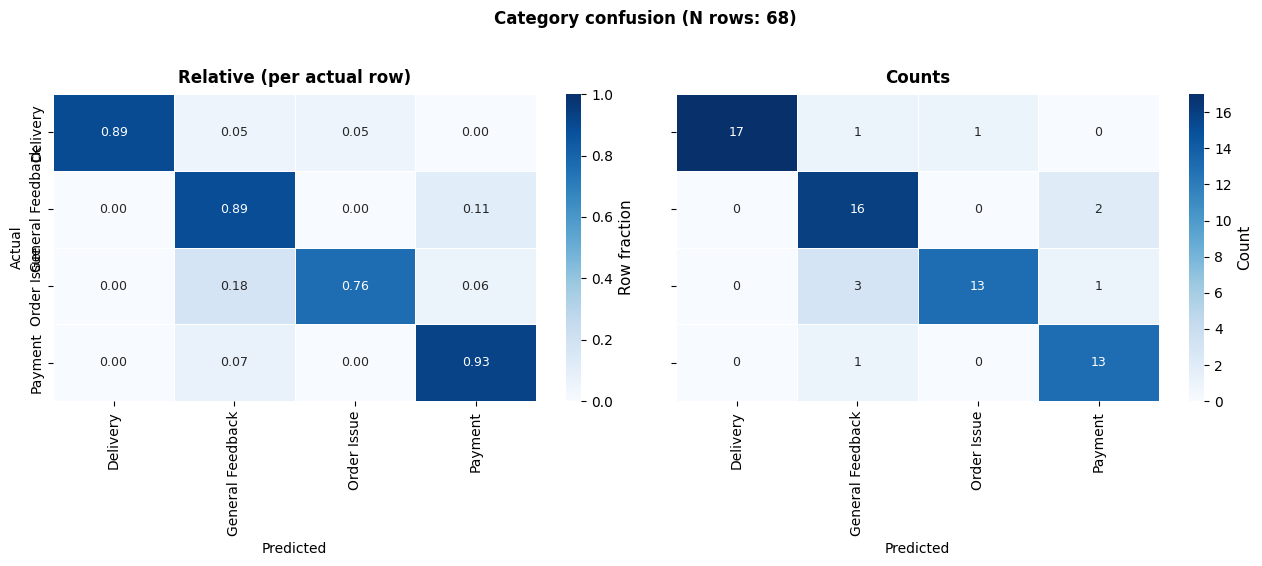

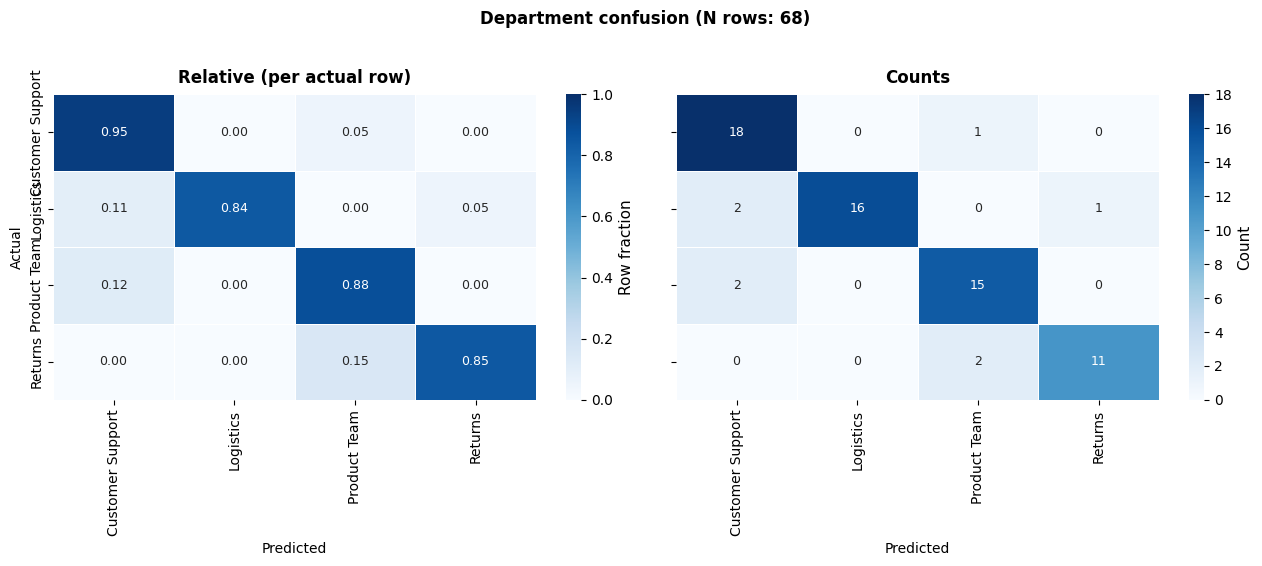

In [38]:
from types import SimpleNamespace

# Metrics + confusion plots (relative + counts) at best n_shot — same helper as main H2
_qm_fs = compute_quality_metrics(eval_df_fixed, phase2_predictions[optimal_n_shot])
print(f"Few-shot ablation — eval at n_shot={optimal_n_shot}")
display_evaluation_results(
    eval_results=SimpleNamespace(quality_metrics=_qm_fs),
)

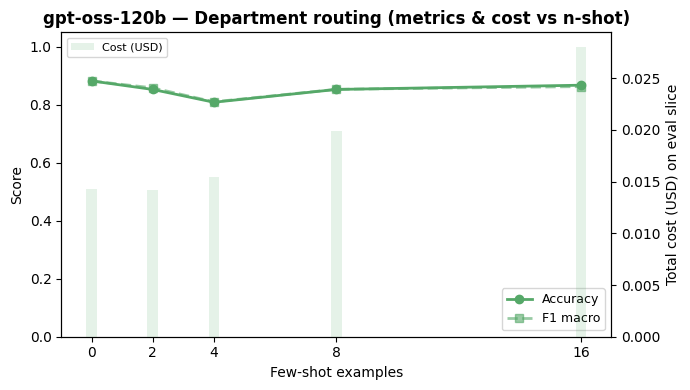

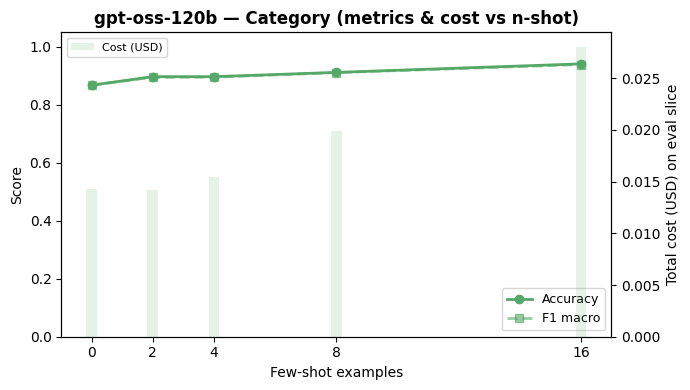

In [39]:
_fs_plot_df = df_few_shot_ablation.sort_values("n_shot")
_color = MODEL_PALETTE.get(BEST_MODEL, "#4C72B0")
_short = BEST_MODEL.rsplit("/", 1)[-1]
_nshots = _fs_plot_df["n_shot"].tolist()

for target, acc_col, f1_col in (
    ("Department routing", "department_accuracy", "department_f1_macro"),
    ("Category", "category_accuracy", "category_f1_macro"),
):
    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax1.plot(
        _fs_plot_df["n_shot"],
        _fs_plot_df[acc_col],
        marker="o",
        lw=2,
        label="Accuracy",
        color=_color,
    )
    ax1.plot(
        _fs_plot_df["n_shot"],
        _fs_plot_df[f1_col],
        marker="s",
        lw=2,
        label="F1 macro",
        color=_color,
        alpha=0.6,
        linestyle="--",
    )
    ax1.set_xlabel("Few-shot examples")
    ax1.set_ylabel("Score")
    ax1.set_ylim(0, 1.05)
    ax1.set_xticks(_nshots)
    ax1.legend(loc="lower right", fontsize=9)

    ax2 = ax1.twinx()
    ax2.bar(
        _fs_plot_df["n_shot"],
        _fs_plot_df["cost_total_usd"],
        width=0.35,
        alpha=0.15,
        color=_color,
        label="Cost (USD)",
    )
    ax2.set_ylabel("Total cost (USD) on eval slice")
    ax2.legend(loc="upper left", fontsize=8)

    ax1.set_title(
        f"{_short} — {target} (metrics & cost vs n-shot)",
        fontweight="bold",
    )
    fig.tight_layout()
    plt.show()

## Safety guardrail via confidence

In [44]:
from ai_leader.evaluation import compute_confidence_policy_metrics

confidence_metrics = compute_confidence_policy_metrics(
    df,
    h2_run.predictions,
    high_label=HIGH_CONFIDENCE_LABEL,
)

pprint(confidence_metrics)

confidence_counts = h2_run.predictions["Confidence"].fillna("Unknown").value_counts().reset_index()
confidence_counts.columns = ["confidence", "count"]
confidence_counts

{'high_confidence_coverage': 0.96,
 'high_confidence_error_rate': 0.5520833333333333,
 'manual_review_rate': 0.040000000000000036}


,confidence,count
0,High,96
1,Medium,4


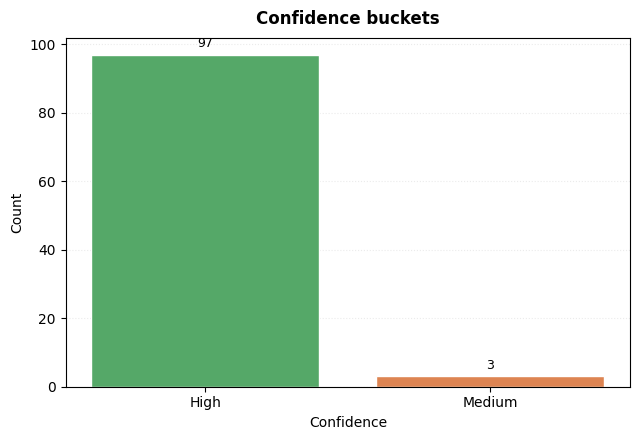

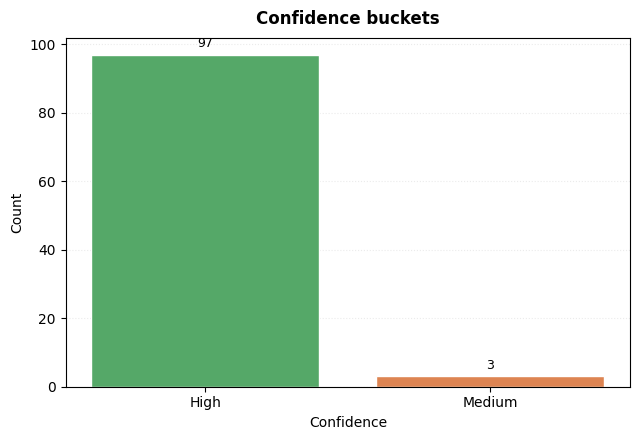

In [22]:
plot_confidence_buckets(confidence_counts)

## H6 — Cost

In [23]:
cost_metrics = h2_run.cost_metrics.copy()
cost_metrics["monthly_messages"] = MONTHLY_MESSAGES
pprint(cost_metrics)

{'annual_cost_usd': 41.26176,
 'cost_per_exact_match_usd': 0.0003737478260869565,
 'cost_per_message_usd': 0.000171924,
 'monthly_cost_usd': 3.43848,
 'monthly_messages': 20000}


## H7 — Latency

In [24]:
pprint(h2_run.latency_metrics)

{'median_latency_ms': 1428.411895496538, 'p95_latency_ms': 2341.718266993121}


## Final recommendation

In [25]:
recommendation = {
    "model": h2_model,
    "exact_match_rate": h2_run.quality_metrics["exact_route_match_rate"],
    "misroute_rate": h2_run.quality_metrics["misroute_rate"],
    "high_confidence_coverage": confidence_metrics["high_confidence_coverage"],
    "high_confidence_error_rate": confidence_metrics["high_confidence_error_rate"],
    "monthly_cost_usd": h2_run.cost_metrics["monthly_cost_usd"],
    "median_latency_ms": h2_run.latency_metrics["median_latency_ms"],
}

pprint(recommendation)

{'exact_match_rate': 0.46,
 'high_confidence_coverage': 0.97,
 'high_confidence_error_rate': 0.5257731958762887,
 'median_latency_ms': 1428.411895496538,
 'misroute_rate': 0.54,
 'model': 'deepseek-ai/DeepSeek-V3.2',
 'monthly_cost_usd': 3.43848}


## Optional appendix

Add few-shot experiments or prompt refinements below if desired.